In [13]:
import random
import math
import numpy as np
from collections import deque
from typing import Optional


Point2D = tuple[float, float]
RectangleRegion = tuple[float, float, float, float]

#=====================================
# PRIVATE HELPERS
#=====================================

def _is_connected(points: list[Point2D], radius: float) -> bool:
    """
    Checks whether the geometric graph induced by the point set is connected.

    Two points are adjacent if their Euclidean distance is <= radius.

    Parameters
    ----------
    points : list[(float, float)]
        Set of 2D coordinates.
    radius : float
        Communication radius.

    Returns
    -------
    bool
        True if the graph is connected, False otherwise.
    """
    if not points:
        return True

    visited: set[int] = set()
    queue: deque[int] = deque([0])

    adjacency: dict[int, list[int]] = {i: [] for i in range(len(points))}

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            if math.dist(points[i], points[j]) <= radius:
                adjacency[i].append(j)
                adjacency[j].append(i)

    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.add(node)
            queue.extend(adjacency[node])

    return len(visited) == len(points)


def _get_components(points: list[Point2D], radius: float) -> list[list[int]]:
    """
    Computes connected components of the geometric graph.
    """
    components: list[list[int]] = []
    visited: set[int] = set()

    for i in range(len(points)):
        if i in visited:
            continue

        component: list[int] = []
        queue: deque[int] = deque([i])

        while queue:
            node = queue.popleft()
            if node not in visited:
                visited.add(node)
                component.append(node)

                for j in range(len(points)):
                    if j != node and math.dist(points[node], points[j]) <= radius:
                        queue.append(j)

        components.append(component)

    return components


def _fallback_insert_point(
    points: list[Point2D],
    region: RectangleRegion,
    radius: float,
    rng: random.Random,
) -> Point2D:
    """
    Executes the fallback insertion strategy when no valid best_point
    is found during stochastic sampling.

    Strategy hierarchy:
    1) Try to connect disconnected components.
    2) Otherwise perform anchored random insertion.
    """
    x_min, y_min, x_max, y_max = region

    # -------------------------------------------------
    # Try to connect components
    # -------------------------------------------------
    if len(points) > 1:
        components = _get_components(points, radius)

        if len(components) > 1:
            comp1, comp2 = rng.sample(components, 2)
            p1 = points[rng.choice(comp1)]
            p2 = points[rng.choice(comp2)]

            mid_x = (p1[0] + p2[0]) / 2
            mid_y = (p1[1] + p2[1]) / 2

            direction = math.atan2(p2[1] - p1[1], p2[0] - p1[0])

            new_x = mid_x + rng.uniform(-0.3 * radius, 0.3 * radius) * math.sin(direction)
            new_y = mid_y + rng.uniform(-0.3 * radius, 0.3 * radius) * math.cos(direction)

            new_x = float(np.clip(new_x, x_min, x_max))
            new_y = float(np.clip(new_y, y_min, y_max))

            return (new_x, new_y)

    # -------------------------------------------------
    # Anchored random insertion
    # -------------------------------------------------
    anchor = rng.choice(points)

    angle = rng.uniform(0, 2 * math.pi)
    distance = rng.uniform(0, radius)

    new_x = anchor[0] + distance * math.cos(angle)
    new_y = anchor[1] + distance * math.sin(angle)

    new_x = float(np.clip(new_x, x_min, x_max))
    new_y = float(np.clip(new_y, y_min, y_max))

    return (new_x, new_y)


def _repair_connectivity(
    points: list[Point2D],
    radius: float,
    rng: random.Random,
) -> list[Point2D]:
    """
    Ensures global connectivity by iteratively inserting midpoint relays
    between disconnected components.
    """
    components = _get_components(points, radius)

    while len(components) > 1:
        comp1, comp2 = rng.sample(components, 2)

        p1 = points[rng.choice(comp1)]
        p2 = points[rng.choice(comp2)]

        mid_x = (p1[0] + p2[0]) / 2
        mid_y = (p1[1] + p2[1]) / 2

        points.append((mid_x, mid_y))

        components = _get_components(points, radius)

    return points


#=====================================
# PUBLIC API
#=====================================

def continuous_network_gen(
    amount: int,
    region: RectangleRegion,
    radius: float,
    sink: Point2D,
    rng: random.Random = random.Random(),
    max_attempts: int = 100
) -> list[Point2D]:
    """
    Generates spatial points attempting to maximize coverage while
    preserving geometric connectivity.

    Growth model:
    - Seed at region center.
    - Iteratively sample anchored candidates.
    - Select the point maximizing minimum distance.
    - Apply fallback insertion when sampling fails.
    - Perform final connectivity repair if necessary.

    Parameters
    ----------
    amount : int
        Number of points to generate.
    region : (x_min, y_min, x_max, y_max)
        Rectangular spatial domain.
    radius : float
        Communication radius.
    sink: (float, float)
        Sink position (if None, uses region center).
    rng : random.Random
        RNG for reproducibility.
    max_attempts : int
        Candidate samples per iteration.

    Returns
    -------
    list[(float, float)]
        Generated point set.
    """
    if amount <= 0:
        return []

    x_min, y_min, x_max, y_max = region

    points: list[Point2D] = []

    # -------------------------------------------------
    # Sink position or seed at geometric center as sink
    # -------------------------------------------------
    first_x = sink[0] if sink else (x_min + x_max) / 2
    first_y = sink[1] if sink else (y_min + y_max) / 2
    points.append((first_x, first_y))

    # -------------------------------------------------
    # Growth process
    # -------------------------------------------------
    while len(points) < amount + 1: # +1 for sink

        best_point: Optional[Point2D] = None
        max_min_distance = 0.0

        for _ in range(max_attempts):

            anchor = rng.choice(points)

            angle = rng.uniform(0, 2 * math.pi)
            distance = rng.uniform(0.5 * radius, radius)

            new_x = anchor[0] + distance * math.cos(angle)
            new_y = anchor[1] + distance * math.sin(angle)

            if not (x_min <= new_x <= x_max and y_min <= new_y <= y_max):
                continue

            candidate = (new_x, new_y)
            temp_points = points + [candidate]

            if _is_connected(temp_points, radius):

                min_dist = min(math.dist(candidate, p) for p in points)

                if min_dist > max_min_distance:
                    max_min_distance = min_dist
                    best_point = candidate

        # -------------------------------------------------
        # Insert best candidate or fallback
        # -------------------------------------------------
        if best_point is not None:
            points.append(best_point)
        else:
            new_point = _fallback_insert_point(points, region, radius, rng)
            points.append(new_point)

    # -------------------------------------------------
    # Final repair
    # -------------------------------------------------
    if not _is_connected(points, radius):
        points = _repair_connectivity(points, radius, rng)

    return points

Node 0: (0, 0)
Node 1: (48.44046666196076, 11.209092456551522)
Node 2: (-11.768862128944585, -48.191315968542575)
Node 3: (47.75521420521378, -38.150866402546704)
Node 4: (-3.6778274901318313, 49.15858565065047)
Node 5: (-57.81034673640998, -30.876236271995815)
Node 6: (-35.88602054373565, 86.34460153653461)
Node 7: (22.17162622211174, -83.9478484428504)
Node 8: (43.51912584951298, 62.388885787965144)
Node 9: (93.32554270548884, -22.34487301641101)
Node 10: (-60.70105159374961, 45.698889299895434)
Node 11: (-91.85335975097807, 7.703472040688915)
Node 12: (-88.95364166795423, -67.21652286214385)
Node 13: (80.82597021522857, 94.84506038171587)
Node 14: (65.81647564198985, -81.9402679369314)
Node 15: (92.2639213711628, 33.40542722548329)
Node 16: (-56.35870975243163, -94.7334346862719)
Node 17: (31.74421820773572, 98.52881146358615)
Node 18: (-76.46610521581312, 91.12413923168883)
Node 19: (-97.32479911683191, 60.54269646407974)
Node 20: (-41.5329890398451, 4.707901911684715)
Node 21: (-5

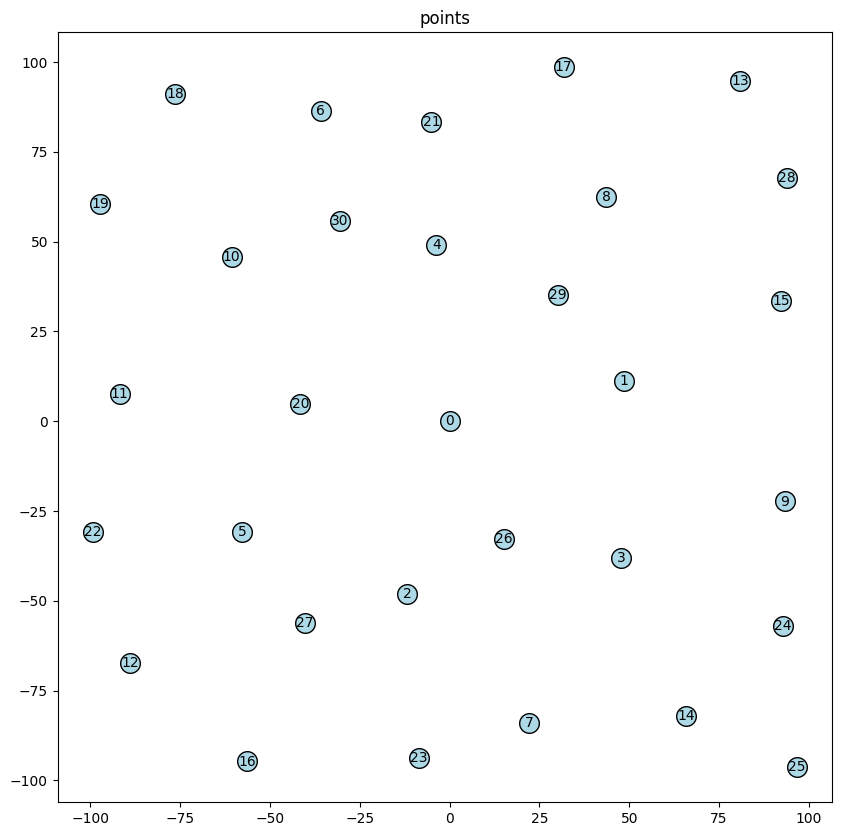

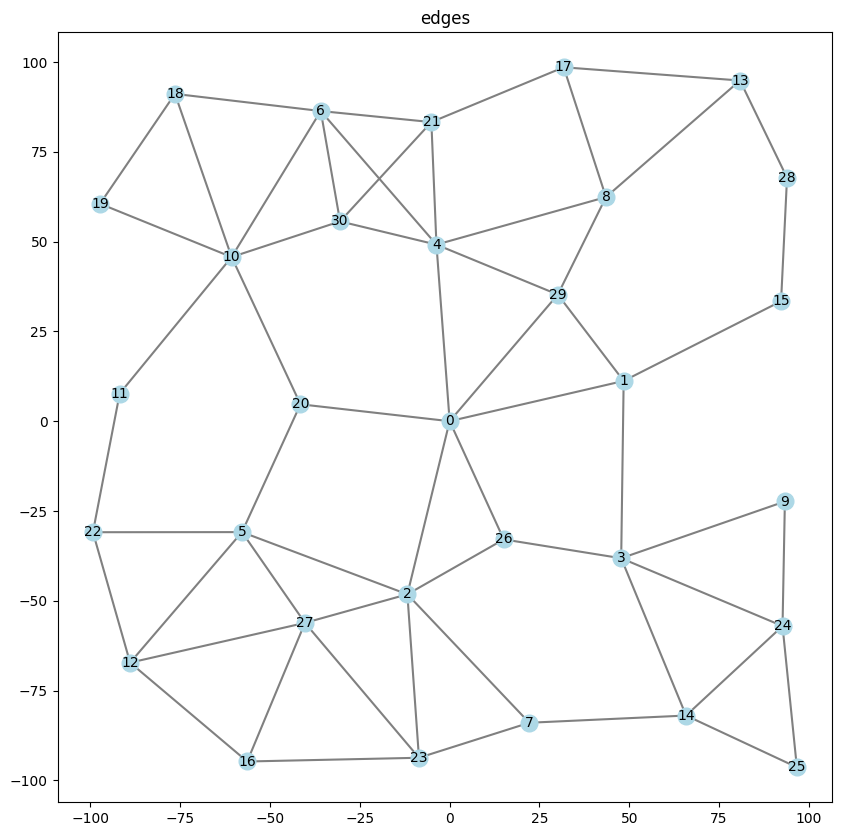

In [14]:
import matplotlib.pyplot as plt

points = continuous_network_gen(
    amount=30,
    region=(-100, -100, 100, 100),
    radius=50,
    sink=(0, 0))

positions: dict[int, tuple[float, float]] = {}

for i, p in enumerate(points):
    positions[i] = p
    print(f"Node {i}: {p}")
    
plt.figure(figsize=(10,10))
for node,(x,y) in positions.items():
    plt.scatter(x,y,color="lightblue",s=200,zorder=2,edgecolor="black",linewidth=1)
    plt.text(x, y,str(node), ha='center', va='center')
plt.title("points")
plt.gca().set_aspect('equal')
plt.show()

R = 50
edges = []

for i in range(len(points)):
    for j in range(i+1, len(points)):
        p1 = points[i]
        p2 = points[j]
        distance = ((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2) ** 0.5
        if distance <= R:
            edges.append((i, j))
            
plt.figure(figsize=(10,10))
for node,(x,y) in positions.items():
    plt.plot(x,y,'o', markersize=12,color="lightblue")
    plt.text(x,y, str(node), ha='center', va='center', color='black') 
for i, j in edges:
    x1, y1 = positions[i]
    x2, y2 = positions[j]
    plt.plot([x1, x2], [y1, y2], color="gray", zorder=1)
    
plt.title("edges")
plt.gca().set_aspect('equal')
plt.show()

In [15]:
def generate_nddr(
    root: tuple[float,float], 
    edges: list[tuple[int,int]]
    )-> list[tuple[int,int,int]]:
    adj = {}
    for u,v in edges:
        adj.setdefault(u, []).append(v)
        adj.setdefault(v, []).append(u)
    visited = set()
    nddr = []
    def dfs(node, depth):
        visited.add(node)
        degree = len(adj[node])
        nddr.append((node, depth, degree))
        for neigh in adj[node]:
            if neigh not in visited:
                dfs(neigh, depth+1)
    dfs(root,0)
    return nddr


def subtree_nodes(nddr: list[tuple[int,int,int]], idx: int) -> list[int]:
    node, depth, _ = nddr[idx]
    result = [node]
    i = idx + 1
    while i < len(nddr) and nddr[i][1] > depth:
        result.append(nddr[i][0])
        i += 1
    return result


def tree_from_parent(parent: list[tuple[int,int,int]]) -> list[tuple[int,int]]:
    edges = []
    for i in range(1,len(parent)):
        node, depth, _ = parent[i]
        for j in range(i-1,-1,-1):
            if parent[j][1] == depth-1:
                edges.append((node,parent[j][0]))
                break
    return edges


def generate_random_tree(
    nodes: list[tuple[float,float]], 
    base_edges: list[tuple[int,int]]
    ) -> list[tuple[int,int]]:
    visited = {0}
    edges = []
    while len(visited) < len(nodes):
        possible = [e for e in base_edges if (e[0] in visited) ^ (e[1] in visited)]
        e = random.choice(possible)
        edges.append(e)
        visited.add(e[0])
        visited.add(e[1])
    return edges

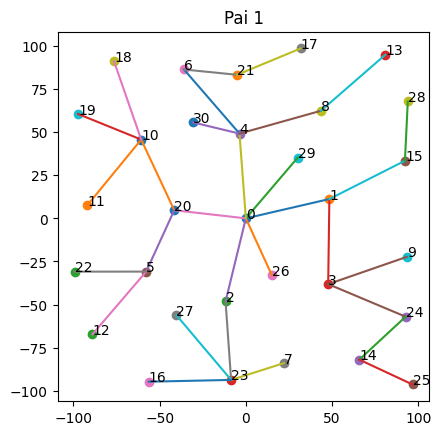

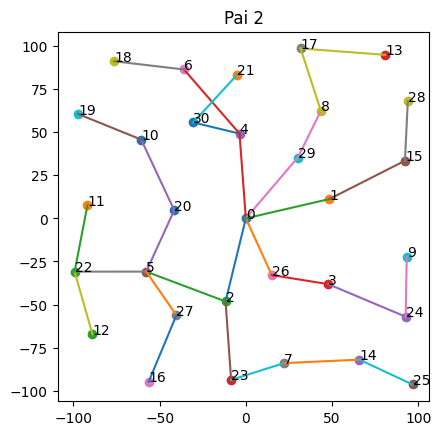

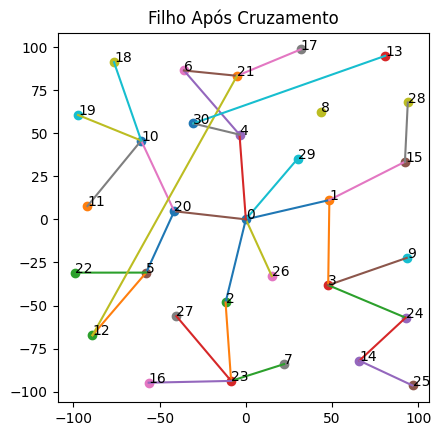

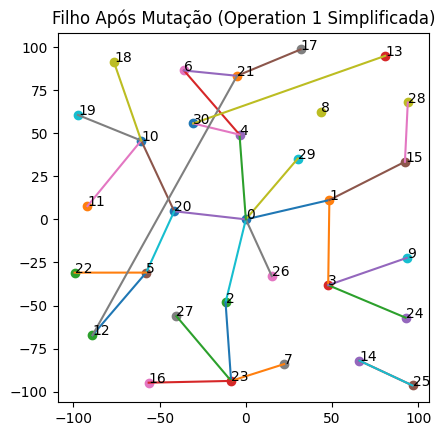

In [16]:
def plot_tree(edges, title):
    plt.figure()
    for (u,v) in edges:
        x = [positions[u][0], positions[v][0]]
        y = [positions[u][1], positions[v][1]]
        plt.plot(x,y)
    for node,(x,y) in positions.items():
        plt.scatter(x,y)
        plt.text(x+0.05,y+0.05,str(node))
    plt.title(title)
    plt.gca().set_aspect('equal')
    plt.show()
    
# ------------------------------
# 1) Gerar dois pais aleatórios
# ------------------------------

parent1_edges = generate_random_tree(points, edges)
parent2_edges = generate_random_tree(points, edges)

parent1_nddr = generate_nddr(0,parent1_edges)
parent2_nddr = generate_nddr(0,parent2_edges)

plot_tree(parent1_edges,"Pai 1")
plot_tree(parent2_edges,"Pai 2")


# ------------------------------
# 2) Cruzamento (troca de subárvore)
# ------------------------------

# Escolhe índice aleatório (não raiz)
idx1 = random.randint(1,len(parent1_nddr)-1)
idx2 = random.randint(1,len(parent2_nddr)-1)

sub1 = subtree_nodes(parent1_nddr, idx1)
sub2 = subtree_nodes(parent2_nddr, idx2)

# Cruzamento simples: troca nós mantendo profundidades
child_nddr = parent1_nddr.copy()

# substitui nó raiz da subárvore
node_to_replace = child_nddr[idx1][0]
replacement = parent2_nddr[idx2]

child_nddr[idx1] = replacement

child_edges = tree_from_parent(child_nddr)

plot_tree(child_edges,"Filho Após Cruzamento")


# ------------------------------
# 3) Mutação (Operation 1 simplificada)
# ------------------------------

mut_edges = child_edges.copy()

# remove aresta aleatória e reconecta folha aleatória
u,v = random.choice(mut_edges)
mut_edges.remove((u,v))

# escolhe novo nó pai aleatório
leaf = u
possible_parents = [n for n in positions.keys() if n != leaf]
new_parent = random.choice(possible_parents)
mut_edges.append((leaf,new_parent))

mut_nddr = generate_nddr(0,mut_edges)

plot_tree(mut_edges,"Filho Após Mutação (Operation 1 Simplificada)")